# Diabetes Risk Prediction Using Machine Learning

**Author:** Chinonye Anams

**Tools:**  Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

---

## Problem Statement

Early detection of diabetes is critical for preventing long-term complications. 
This project analyzes clinical health indicators and builds a machine learning model to predict diabetes risk.

## Importing Library

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

## Data Loading and Inspection

In [39]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


## Target Distribution

In [24]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [25]:
df['Outcome'].value_counts(normalize=True)

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

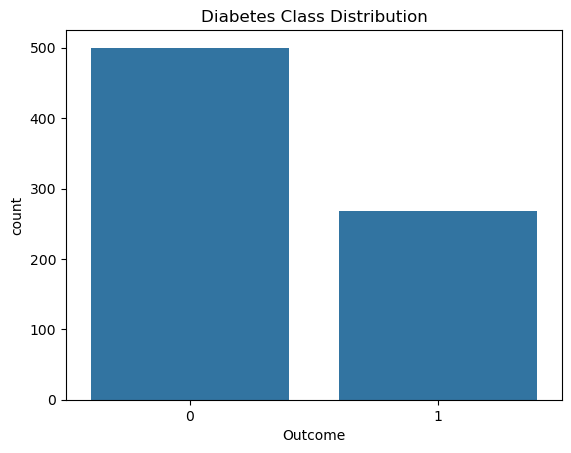

In [41]:
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Class Distribution")
plt.show()

The dataset contains 768 patients, of which 268 (34.9%) were diagnosed with diabetes. While the classes are slightly imbalanced, the distribution remains suitable for predictive modeling without requiring aggressive resampling techniques.

## Data Quality Check

In [26]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


A review of summary statistics showed no physiologically implausible zero values in key clinical variables such as glucose and BMI. This suggests the dataset has undergone prior preprocessing and is suitable for direct modeling.

## EDA - Feature Relationships

### Glucose vs Diabetes

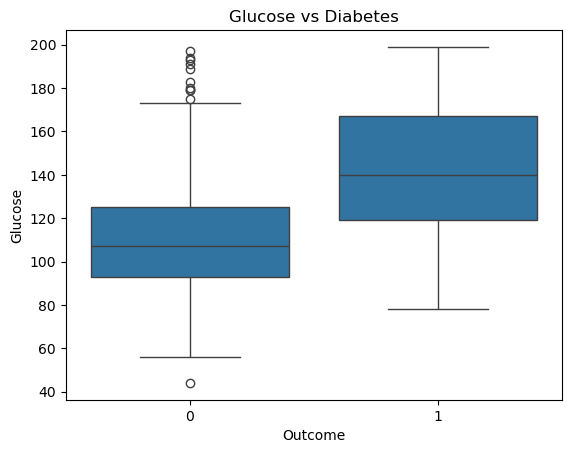

In [27]:
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title("Glucose vs Diabetes")
plt.show()

Patients diagnosed with diabetes exhibit significantly higher glucose levels, with a median around 140 compared to below 120 in non-diabetic patients. This aligns with clinical expectations, as elevated blood glucose is a primary diagnostic marker for diabetes.

### BMI vs Diabetes

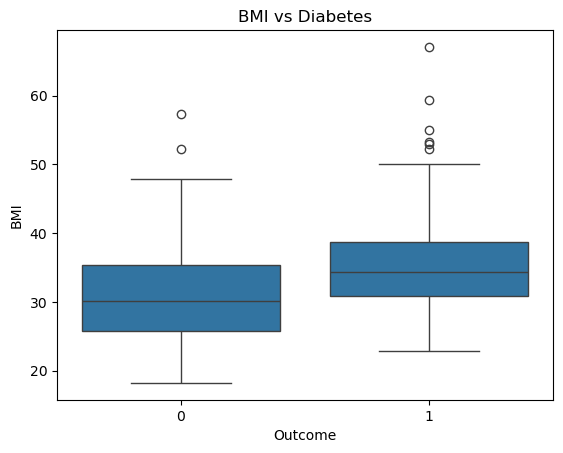

In [28]:
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.title("BMI vs Diabetes")
plt.show()

Diabetic patients show slightly higher BMI values, with medians just above 30 compared to around 30 in non-diabetic individuals. Although the separation is less pronounced than glucose, the trend supports the established link between higher body mass and increased diabetes risk.

### Age vs Diabetes

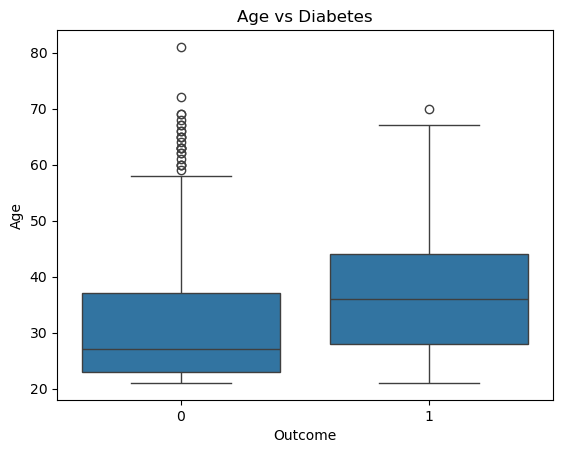

In [29]:
sns.boxplot(x='Outcome', y='Age', data=df)
plt.title("Age vs Diabetes")
plt.show()

Diabetic patients tend to be older, with a median age above 30 compared to below 30 for non-diabetic individuals. This aligns with epidemiological trends, as diabetes risk increases with age due to cumulative metabolic and lifestyle factors.

### Correlation Analysis

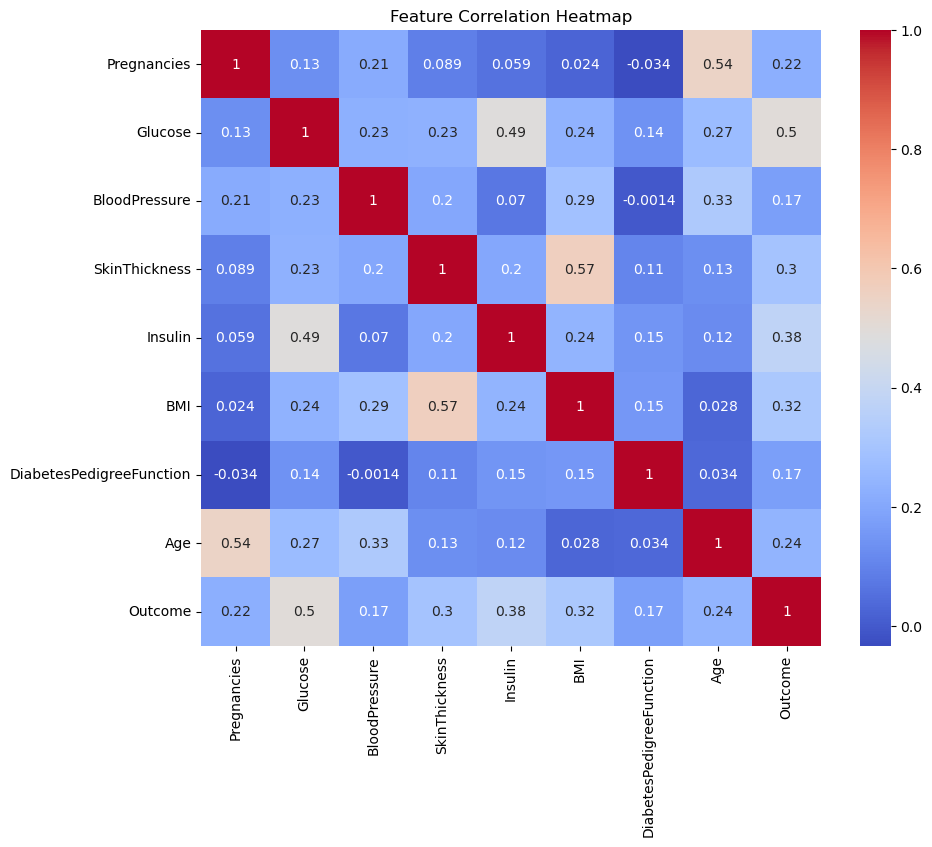

In [30]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

The correlation heatmap indicates that glucose has the strongest association with diabetes. Insulin, BMI, and skin thickness show moderate correlations, while age exhibits a weaker but still positive relationship with diabetes risk.

## Modeling

### Feature Selection and Scaling

In [31]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((614, 8), (154, 8))

The dataset was split into training and testing sets using an 80:20 ratio to evaluate model performance on unseen data.

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Building and Evaluation — Logistic Regression

In [33]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [34]:
y_pred = model.predict(X_test)

In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.84      0.83        99
           1       0.69      0.65      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



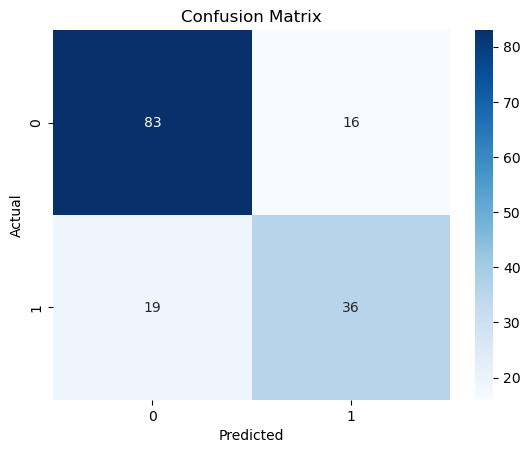

In [36]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### Logistic Regression Performance

The logistic regression model demonstrated balanced performance across classes. It achieved strong results for non-diabetic cases and a recall of approximately 0.65 for diabetic patients.

This means the model correctly identifies around 65% of diabetes cases, making it a reasonable baseline model for screening purposes. However, improvements may be possible through more advanced algorithms or feature engineering.

### Model Building and Evaluation — Random Forest

In [37]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [38]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.93      0.89      0.91        99
           1       0.81      0.87      0.84        55

    accuracy                           0.88       154
   macro avg       0.87      0.88      0.87       154
weighted avg       0.89      0.88      0.88       154



#### Random Forest Performance

The random forest model significantly outperformed logistic regression, achieving an accuracy of 88% and a recall of 0.87 for diabetic patients.

This represents a substantial improvement over the baseline model, which achieved a recall of 0.65. The results highlight the effectiveness of ensemble methods in capturing complex nonlinear relationships in clinical data.

Given the importance of minimizing missed diagnoses, the random forest model provides a more suitable approach for diabetes risk prediction.

## Model Comparison

| Model | Accuracy | Recall (Diabetes) |
|------|---------|------------------|
| Logistic Regression | 0.77 | 0.65 |
| Random Forest | 0.88 | 0.87 |

The random forest model demonstrated superior performance across all key metrics, particularly in identifying diabetic cases.

## Conclusion

This study explored clinical risk factors associated with diabetes and developed predictive models to identify high-risk individuals. Exploratory analysis revealed glucose as the strongest predictor, with additional contributions from BMI and age.

Among the models evaluated, random forest achieved the best performance, delivering high accuracy and strong recall for diabetic cases. These findings suggest that machine learning can effectively support early diabetes risk detection and may serve as a foundation for clinical decision support tools.